In [1]:
!pip install -q torchmetrics torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 9.0 MB/s eta 0:00:00


In [2]:
import os, glob, time, random, json
from dataclasses import dataclass, asdict
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid, save_image


@dataclass
class CFG:
    seed: int = 42
    img_size: int = 64
    z_dim: int = 100
    batch_size: int = 128
    epochs: int = 25
    lr: float = 2e-4
    beta1: float = 0.5
    real_label: float = 0.9        # one-sided label smoothing
    fid_every: int = 5             # epochs between FID evaluations
    fid_samples: int = 5000        # images used per FID evaluation
    num_workers: int = 2
    ckpt_dir: str = "/content/checkpoints"
    out_dir: str = "/content/outputs"


cfg = CFG()
os.makedirs(cfg.ckpt_dir, exist_ok=True)
os.makedirs(cfg.out_dir, exist_ok=True)


def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


set_seed(cfg.seed)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print(json.dumps(asdict(cfg), indent=2))

device: cuda
{
  "seed": 42,
  "img_size": 64,
  "z_dim": 100,
  "batch_size": 128,
  "epochs": 25,
  "lr": 0.0002,
  "beta1": 0.5,
  "real_label": 0.9,
  "fid_every": 5,
  "fid_samples": 5000,
  "num_workers": 2,
  "ckpt_dir": "/content/checkpoints",
  "out_dir": "/content/outputs"
}


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Path to dataset files: /kaggle/input/celeba-dataset


## 2. Data

CelebA aligned faces from Kaggle. Each image is center-cropped to the face region (148×148), resized to 64×64, randomly flipped, and normalised to [-1, 1] to match the generator's `tanh` output.

In [5]:
import os, getpass
!pip install -q -U kaggle

os.makedirs("/root/.kaggle", exist_ok=True)
token = getpass.getpass("Kaggle API token: ")   # hidden input, never saved in the notebook
with open("/root/.kaggle/access_token", "w") as f:
    f.write(token)
os.chmod("/root/.kaggle/access_token", 0o600)
os.environ["KAGGLE_API_TOKEN"] = token          # fallback some versions read

!kaggle datasets download -d jessicali9530/celeba-dataset -q
!unzip -q -o celeba-dataset.zip -d celeba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 12.4 MB/s eta 0:00:00
Kaggle API token: ··········
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other


In [3]:
from google.colab import files
files.upload()   # upload kaggle.json

{}

In [ ]:
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!kaggle datasets download -d jessicali9530/celeba-dataset -q
!unzip -q -o celeba-dataset.zip -d celeba

202,599 images, 1582 batches/epoch


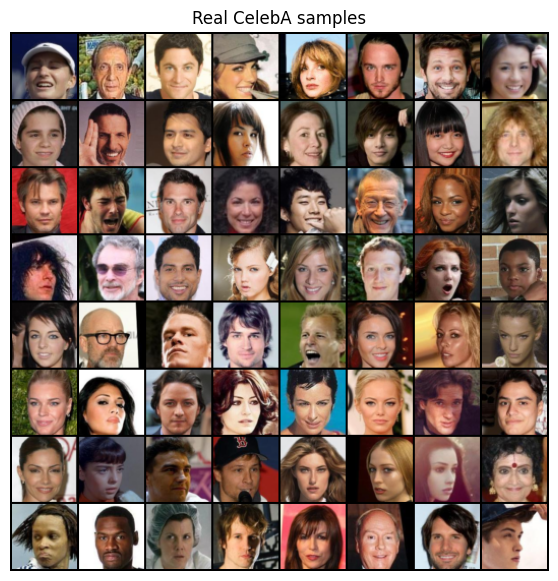

In [6]:
transform = transforms.Compose([
    transforms.CenterCrop(148),
    transforms.Resize(cfg.img_size),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3),   # -> [-1, 1]
])


class CelebAFaces(Dataset):
    def __init__(self, root, transform):
        self.paths = sorted(glob.glob(os.path.join(root, "**", "*.jpg"), recursive=True))
        assert len(self.paths) > 0, f"No images found under {root}"
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        return self.transform(Image.open(self.paths[i]).convert("RGB"))


dataset = CelebAFaces("/content/celeba/img_align_celeba", transform)
loader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=True,
                    num_workers=cfg.num_workers, pin_memory=True, drop_last=True)
print(f"{len(dataset):,} images, {len(loader)} batches/epoch")

# Quick look at real data
real_batch = next(iter(loader))
plt.figure(figsize=(7, 7))
plt.imshow(make_grid(real_batch[:64] * 0.5 + 0.5, nrow=8).permute(1, 2, 0))
plt.axis("off"); plt.title("Real CelebA samples"); plt.show()

## 3. Model

- **Generator:** noise `z ∈ R^100` → 4 transposed-conv blocks (BatchNorm + ReLU) → 64×64×3 image with `tanh`.
- **Discriminator:** 4 strided-conv blocks (BatchNorm + LeakyReLU, no BatchNorm on the first layer) → single logit. The sigmoid is folded into `BCEWithLogitsLoss` for numerical stability.
- Weights initialised from N(0, 0.02) as in the DCGAN paper.

In [7]:
class Generator(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.net = nn.Sequential(
            self._block(z_dim, 512, 4, 1, 0),   # [z,1,1]    -> [512,4,4]
            self._block(512, 256, 4, 2, 1),     #            -> [256,8,8]
            self._block(256, 128, 4, 2, 1),     #            -> [128,16,16]
            self._block(128, 64, 4, 2, 1),      #            -> [64,32,32]
            nn.ConvTranspose2d(64, 3, 4, 2, 1), #            -> [3,64,64]
            nn.Tanh(),
        )

    @staticmethod
    def _block(i, o, k, s, p):
        return nn.Sequential(
            nn.ConvTranspose2d(i, o, k, s, p, bias=False),
            nn.BatchNorm2d(o),
            nn.ReLU(True),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),      # no BatchNorm on input layer
            nn.LeakyReLU(0.2, True),                    # [3,64,64]  -> [64,32,32]
            self._block(64, 128, 4, 2, 1),              #            -> [128,16,16]
            self._block(128, 256, 4, 2, 1),             #            -> [256,8,8]
            self._block(256, 512, 4, 2, 1),             #            -> [512,4,4]
            nn.Conv2d(512, 1, 4, 1, 0),                 #            -> [1,1,1] logit
        )

    @staticmethod
    def _block(i, o, k, s, p):
        return nn.Sequential(
            nn.Conv2d(i, o, k, s, p, bias=False),
            nn.BatchNorm2d(o),
            nn.LeakyReLU(0.2, True),
        )

    def forward(self, x):
        return self.net(x).view(-1)


def weights_init(m):
    name = m.__class__.__name__
    if "Conv" in name:
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif "BatchNorm" in name:
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.zeros_(m.bias)


gen = Generator(cfg.z_dim).to(device)
disc = Discriminator().to(device)
gen.apply(weights_init); disc.apply(weights_init)

n_params = lambda m: sum(p.numel() for p in m.parameters())
print(f"Generator params:     {n_params(gen):,}")
print(f"Discriminator params: {n_params(disc):,}")

# Shape sanity check
with torch.no_grad():
    z = torch.randn(2, cfg.z_dim, 1, 1, device=device)
    print("G(z):", tuple(gen(z).shape), "| D(G(z)):", tuple(disc(gen(z)).shape))

Generator params:     3,576,707
Discriminator params: 2,765,569
G(z): (2, 3, 64, 64) | D(G(z)): (2,)


## 4. Training utilities: optimisers, FID, checkpoints

**FID** compares Inception-v3 feature statistics of real vs generated images (lower is better). Real-image statistics are computed once and reused; each evaluation uses the same number of generated images. FID here is computed on 64×64 images upsampled to 299×299 using a subset of images, so treat it as a *relative* measure for comparing runs, not as a number comparable to published full-scale FID.

In [8]:
criterion = nn.BCEWithLogitsLoss()
opt_gen = optim.Adam(gen.parameters(), lr=cfg.lr, betas=(cfg.beta1, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=cfg.lr, betas=(cfg.beta1, 0.999))

fixed_noise = torch.randn(64, cfg.z_dim, 1, 1, device=device)

# ---- FID setup (real statistics computed once) ----
from torchmetrics.image.fid import FrechetInceptionDistance
fid_metric = FrechetInceptionDistance(feature=2048, normalize=True,
                                      reset_real_features=False).to(device)

def prep_real_fid():
    seen = 0
    for real in loader:
        fid_metric.update((real.to(device) * 0.5 + 0.5).clamp(0, 1), real=True)
        seen += real.size(0)
        if seen >= cfg.fid_samples:
            break

@torch.no_grad()
def compute_fid():
    gen.eval()
    seen = 0
    while seen < cfg.fid_samples:
        z = torch.randn(cfg.batch_size, cfg.z_dim, 1, 1, device=device)
        fake = (gen(z) * 0.5 + 0.5).clamp(0, 1)
        fid_metric.update(fake, real=False)
        seen += fake.size(0)
    score = float(fid_metric.compute())
    fid_metric.reset()          # keeps real stats (reset_real_features=False)
    gen.train()
    return score

prep_real_fid()
print("Real-image FID statistics ready.")

# ---- samples + checkpoints ----
@torch.no_grad()
def save_samples(epoch):
    gen.eval()
    imgs = (gen(fixed_noise).cpu() * 0.5 + 0.5).clamp(0, 1)
    gen.train()
    path = f"{cfg.out_dir}/samples_epoch_{epoch:03d}.png"
    save_image(imgs, path, nrow=8, padding=2)
    return path, imgs

def save_ckpt(epoch, history):
    torch.save({
        "epoch": epoch, "history": history, "cfg": asdict(cfg),
        "gen": gen.state_dict(), "disc": disc.state_dict(),
        "opt_gen": opt_gen.state_dict(), "opt_disc": opt_disc.state_dict(),
    }, f"{cfg.ckpt_dir}/latest.pt")

history = defaultdict(list)
fid_history = []          # list of (epoch, fid)
start_epoch = 0

latest = f"{cfg.ckpt_dir}/latest.pt"
if os.path.exists(latest):                       # resume if a checkpoint exists
    ck = torch.load(latest, map_location=device)
    gen.load_state_dict(ck["gen"]); disc.load_state_dict(ck["disc"])
    opt_gen.load_state_dict(ck["opt_gen"]); opt_disc.load_state_dict(ck["opt_disc"])
    history = defaultdict(list, ck["history"])
    fid_history = history.get("fid", [])
    start_epoch = ck["epoch"] + 1
    print(f"Resumed from epoch {start_epoch}")

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 422MB/s]


Real-image FID statistics ready.


## 5. Training

Each step:
1. **Discriminator:** maximise `log D(x) + log(1 - D(G(z)))`. Real targets are 0.9 instead of 1.0 (one-sided label smoothing) to stop D becoming overconfident.
2. **Generator:** maximise `log D(G(z))` (non-saturating loss).

Diagnostics logged per epoch: mean D loss, mean G loss, mean D(x) and D(G(z)). Healthy training keeps D(x) ≈ 0.6–0.8 and D(G(z)) ≈ 0.2–0.4; D(G(z)) → 0 with G loss exploding signals the discriminator is winning (collapse risk).

Epoch 1/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Epoch 01/25 | D 0.792 | G 4.707 | D(x) 0.74 | D(G(z)) 0.16


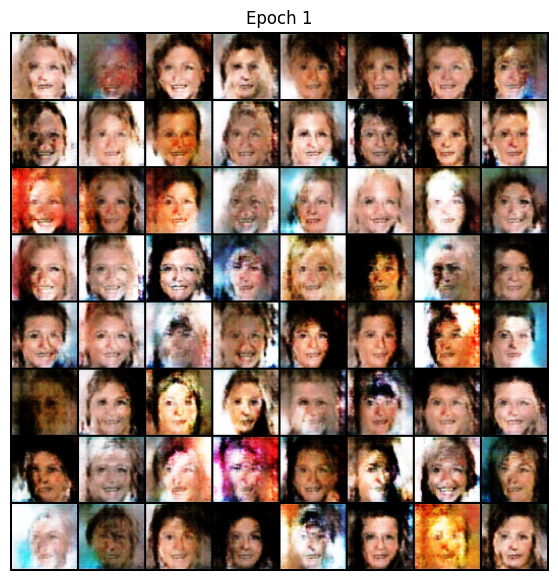

Epoch 2/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1655, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/usr/lib/python3.13/threading.py", line 1088, in join
    raise RuntimeError("cannot join current thread")
RuntimeError: cannot join current thread
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/proc

Epoch 02/25 | D 0.847 | G 3.134 | D(x) 0.70 | D(G(z)) 0.20


Epoch 3/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Epoch 03/25 | D 0.893 | G 2.520 | D(x) 0.67 | D(G(z)) 0.23


Epoch 4/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Epoch 04/25 | D 0.885 | G 2.510 | D(x) 0.67 | D(G(z)) 0.23


Epoch 5/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Traceback (most recent call last):
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 05/25 | D 0.889 | G 2.534 | D(x) 0.67 | D(G(z)) 0.23 | FID 46.5


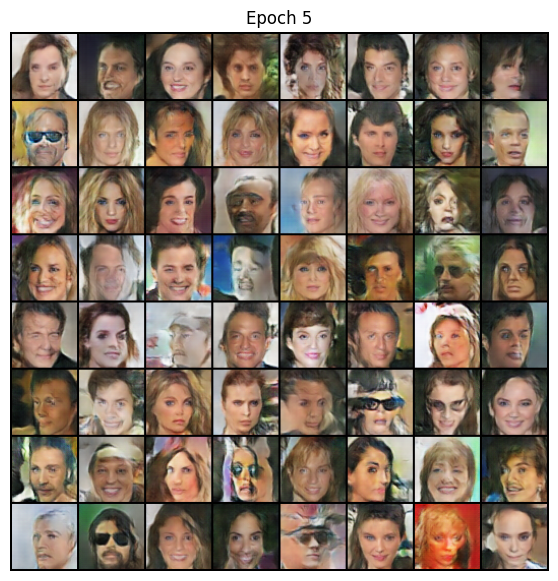

Epoch 6/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Epoch 06/25 | D 0.871 | G 2.504 | D(x) 0.67 | D(G(z)) 0.23


Epoch 7/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    Exception ignored in: if w.is_alive():
<function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    
assert self._parent_pid == os.getpid(), 'can only test a child process'Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    AssertionErrorself._shutdown_workers(): 
can only test a child process  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    
if w.is_alive():
  File "/usr/lib/

Epoch 07/25 | D 0.917 | G 2.452 | D(x) 0.67 | D(G(z)) 0.23


...

Epoch 9/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Epoch 09/25 | D 0.823 | G 2.672 | D(x) 0.70 | D(G(z)) 0.20


Epoch 10/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 10/25 | D 0.751 | G 2.906 | D(x) 0.73 | D(G(z)) 0.17 | FID 32.0


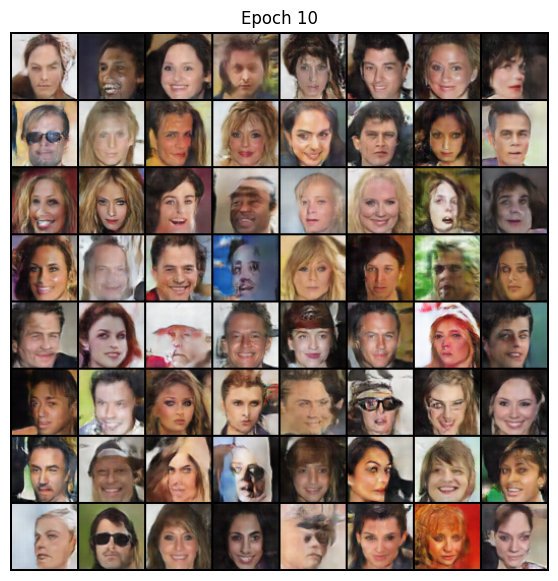

Epoch 11/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Epoch 11/25 | D 0.693 | G 3.129 | D(x) 0.76 | D(G(z)) 0.14


Epoch 12/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
Exception ignored in:     <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>assert self._parent_pid == os.getpid(), 'can only test a child process'
Traceback (most recent call last):

AssertionError  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
:     self._shutdown_workers()can only test a child process

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 12/25 | D 0.716 | G 3.173 | D(x) 0.75 | D(G(z)) 0.14


...

Epoch 14/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Epoch 14/25 | D 0.652 | G 3.388 | D(x) 0.78 | D(G(z)) 0.12


Epoch 15/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers

Traceback (most recent call last):
      File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    if w.is_alive():self._shutdown_workers()

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
        if w.is_alive():
assert self._parent_pid == os.getpid(), 'can only test a child process'
  File "/usr/lib/python3.13/multiprocessing/process.py", line 1

Epoch 15/25 | D 0.654 | G 3.418 | D(x) 0.78 | D(G(z)) 0.12 | FID 29.2


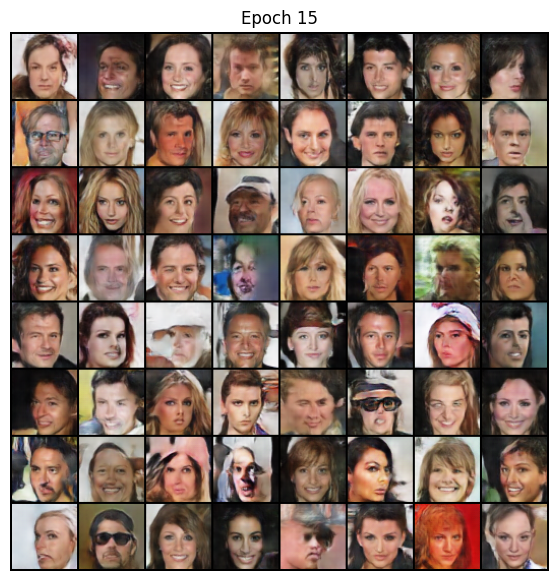

Epoch 16/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Epoch 16/25 | D 0.591 | G 3.592 | D(x) 0.80 | D(G(z)) 0.10


Epoch 17/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():<function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>

Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
        assert self._parent_pid == os.getpid(), 'can only test a child process'self._shutdown_workers()

AssertionError  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
:     can only test a child processif w.is_alive():

  File "/usr/lib/

Epoch 17/25 | D 0.595 | G 3.653 | D(x) 0.80 | D(G(z)) 0.10


...

Epoch 19/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Epoch 19/25 | D 0.585 | G 3.792 | D(x) 0.81 | D(G(z)) 0.09


Epoch 20/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 20/25 | D 0.549 | G 3.886 | D(x) 0.82 | D(G(z)) 0.08 | FID 27.3


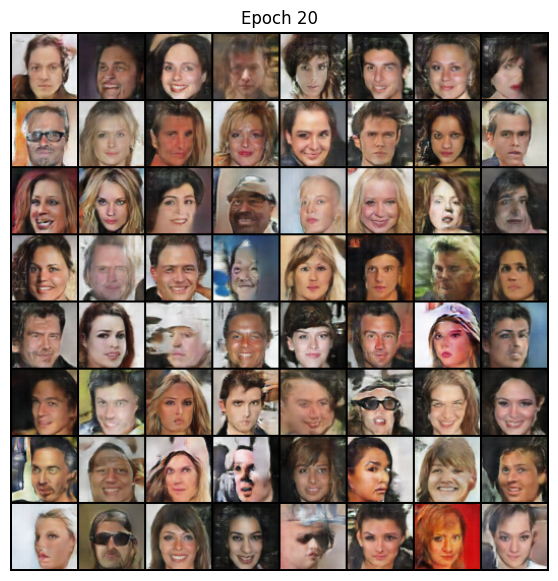

Epoch 21/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Epoch 21/25 | D 0.552 | G 3.894 | D(x) 0.82 | D(G(z)) 0.08


Epoch 22/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():Exception ignored 

Epoch 22/25 | D 0.515 | G 3.999 | D(x) 0.83 | D(G(z)) 0.07


...

Epoch 24/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Epoch 24/25 | D 0.531 | G 4.014 | D(x) 0.83 | D(G(z)) 0.07


Epoch 25/25:   0%|          | 0/1582 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78ceebfb9b20>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 25/25 | D 0.507 | G 4.140 | D(x) 0.84 | D(G(z)) 0.06 | FID 27.5


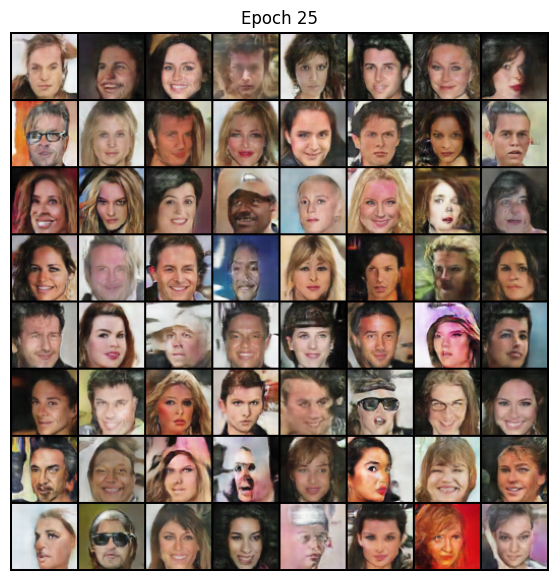

Training time this session: 145.2 min


In [9]:
train_start = time.time()

for epoch in range(start_epoch, cfg.epochs):
    gen.train(); disc.train()
    agg = defaultdict(float); n_batches = 0

    for real in tqdm(loader, desc=f"Epoch {epoch+1}/{cfg.epochs}", leave=False):
        real = real.to(device, non_blocking=True)
        b = real.size(0)
        z = torch.randn(b, cfg.z_dim, 1, 1, device=device)
        fake = gen(z)

        # ---- Discriminator ----
        opt_disc.zero_grad(set_to_none=True)
        d_real = disc(real)
        d_fake = disc(fake.detach())
        loss_d = criterion(d_real, torch.full_like(d_real, cfg.real_label)) + \
                 criterion(d_fake, torch.zeros_like(d_fake))
        loss_d.backward()
        opt_disc.step()

        # ---- Generator ----
        opt_gen.zero_grad(set_to_none=True)
        out = disc(fake)
        loss_g = criterion(out, torch.ones_like(out))
        loss_g.backward()
        opt_gen.step()

        agg["loss_d"] += loss_d.item(); agg["loss_g"] += loss_g.item()
        agg["d_x"] += torch.sigmoid(d_real).mean().item()
        agg["d_gz"] += torch.sigmoid(d_fake).mean().item()
        n_batches += 1

    for k, v in agg.items():
        history[k].append(v / n_batches)

    msg = (f"Epoch {epoch+1:02d}/{cfg.epochs} | "
           f"D {history['loss_d'][-1]:.3f} | G {history['loss_g'][-1]:.3f} | "
           f"D(x) {history['d_x'][-1]:.2f} | D(G(z)) {history['d_gz'][-1]:.2f}")

    if (epoch + 1) % cfg.fid_every == 0 or epoch + 1 == cfg.epochs:
        f = compute_fid()
        fid_history.append((epoch + 1, f)); history["fid"] = fid_history
        msg += f" | FID {f:.1f}"
    print(msg)

    path, imgs = save_samples(epoch + 1)
    if (epoch + 1) % 5 == 0 or epoch == 0 or epoch + 1 == cfg.epochs:
        plt.figure(figsize=(7, 7))
        plt.imshow(make_grid(imgs, nrow=8).permute(1, 2, 0))
        plt.axis("off"); plt.title(f"Epoch {epoch+1}"); plt.show()
    save_ckpt(epoch, dict(history))

train_minutes = (time.time() - train_start) / 60
print(f"Training time this session: {train_minutes:.1f} min")

## 6. Training diagnostics

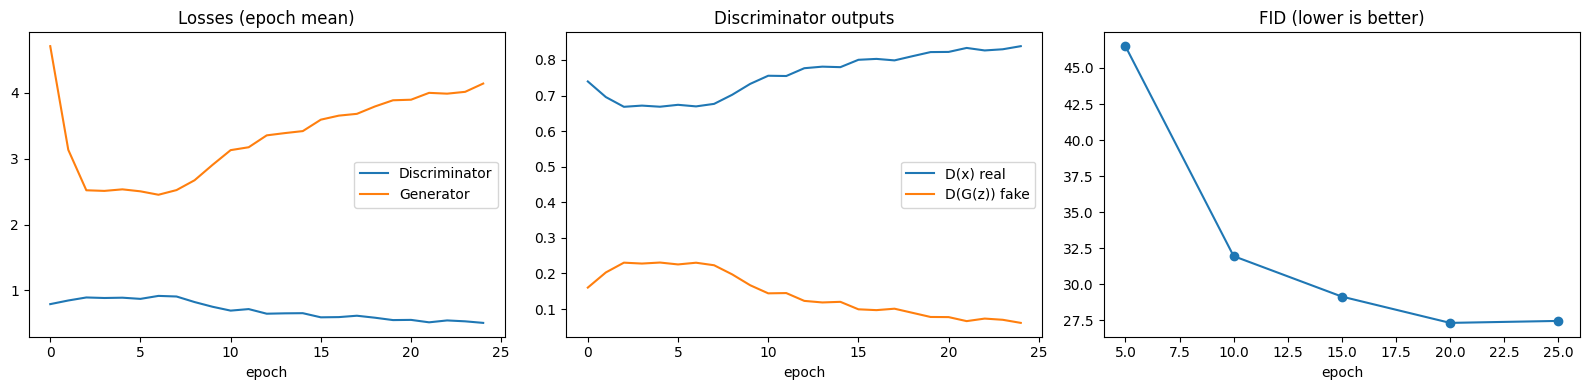

Final FID: 27.5 | Best FID: 27.3


In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(history["loss_d"], label="Discriminator"); ax[0].plot(history["loss_g"], label="Generator")
ax[0].set_title("Losses (epoch mean)"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["d_x"], label="D(x) real"); ax[1].plot(history["d_gz"], label="D(G(z)) fake")
ax[1].set_title("Discriminator outputs"); ax[1].set_xlabel("epoch"); ax[1].legend()
ep, fv = zip(*fid_history)
ax[2].plot(ep, fv, marker="o"); ax[2].set_title("FID (lower is better)"); ax[2].set_xlabel("epoch")
plt.tight_layout(); plt.savefig(f"{cfg.out_dir}/training_curves.png", dpi=150); plt.show()
print("Final FID:", f"{fid_history[-1][1]:.1f}", "| Best FID:", f"{min(v for _, v in fid_history):.1f}")

## 7. Latent-space analysis

If the generator has learned a smooth manifold of faces, walking between two latent points should morph one face into the other gradually, with every in-between frame still looking like a face. We interpolate along the sphere (slerp) rather than a straight line, because high-dimensional Gaussian samples live near a shell and linear interpolation passes through unusually low-norm regions.

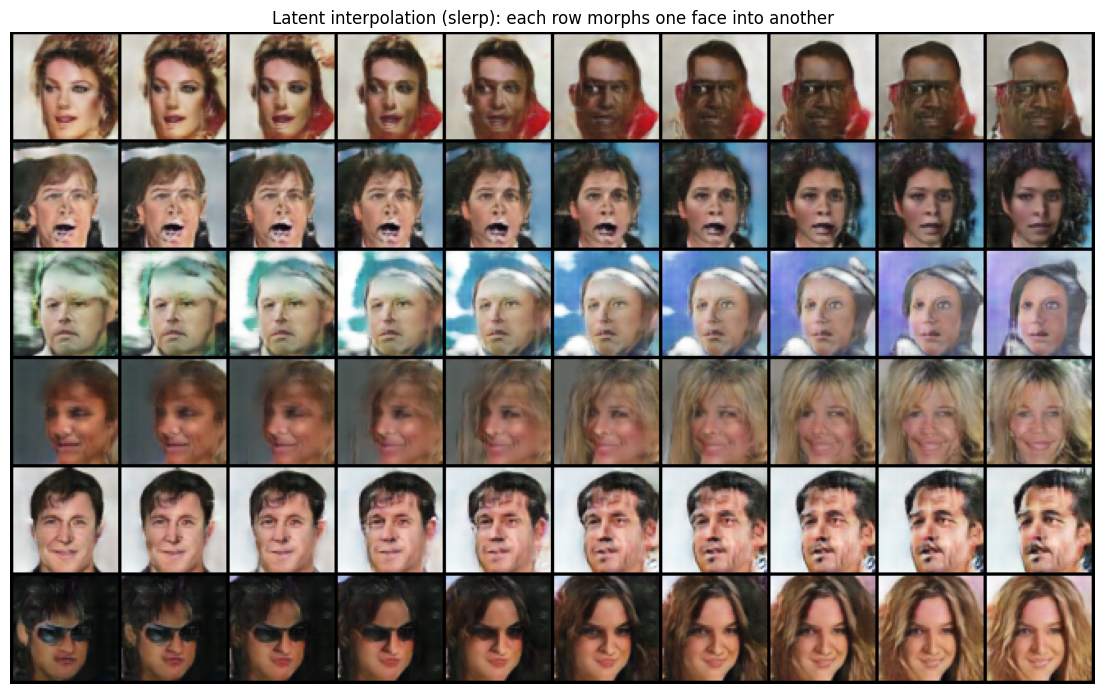

In [11]:
def slerp(a, b, t):
    a_n, b_n = a / a.norm(), b / b.norm()
    omega = torch.acos((a_n * b_n).sum().clamp(-1 + 1e-7, 1 - 1e-7))
    so = torch.sin(omega)
    return (torch.sin((1 - t) * omega) / so) * a + (torch.sin(t * omega) / so) * b

@torch.no_grad()
def interpolation_grid(n_rows=6, steps=10, seed=7):
    gen.eval()
    g = torch.Generator(device="cpu").manual_seed(seed)
    rows = []
    for _ in range(n_rows):
        a = torch.randn(cfg.z_dim, generator=g).to(device)
        b = torch.randn(cfg.z_dim, generator=g).to(device)
        zs = torch.stack([slerp(a, b, t) for t in torch.linspace(0, 1, steps).tolist()])
        rows.append((gen(zs.view(steps, cfg.z_dim, 1, 1)).cpu() * 0.5 + 0.5).clamp(0, 1))
    return torch.cat(rows)

grid = make_grid(interpolation_grid(), nrow=10, padding=2)
plt.figure(figsize=(14, 9)); plt.imshow(grid.permute(1, 2, 0)); plt.axis("off")
plt.title("Latent interpolation (slerp): each row morphs one face into another")
plt.savefig(f"{cfg.out_dir}/interpolation.png", dpi=150, bbox_inches="tight"); plt.show()

**Truncation trick:** sampling `z` from a truncated normal trades diversity for fidelity. Smaller truncation → more typical, cleaner faces but less variety. Same seeds, three settings:

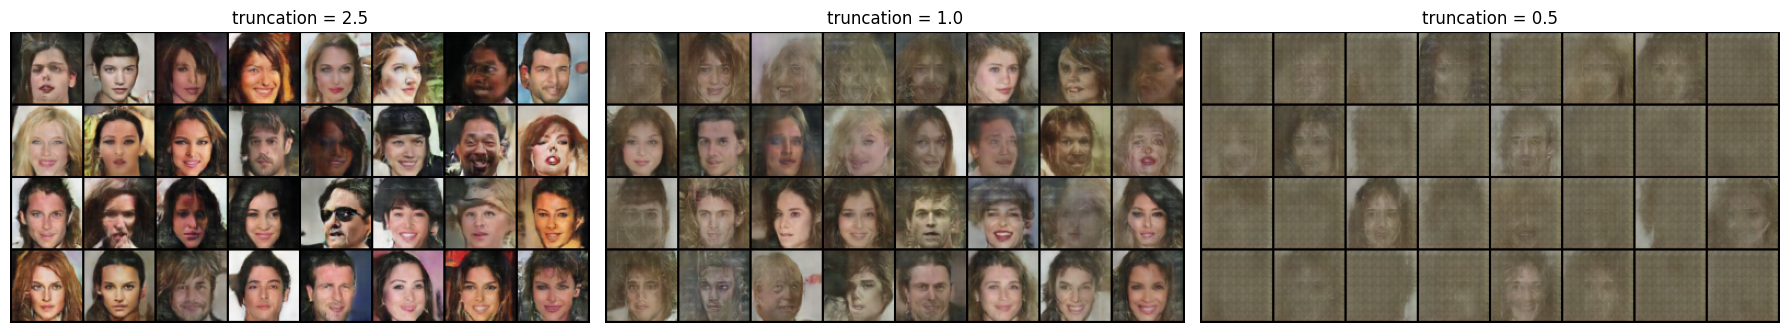

In [12]:
@torch.no_grad()
def sample_truncated(n, trunc, seed=0):
    gen.eval()
    g = torch.Generator(device="cpu").manual_seed(seed)
    z = torch.randn(n, cfg.z_dim, 1, 1, generator=g)
    # resample entries outside [-trunc, trunc]
    while (mask := z.abs() > trunc).any():
        z[mask] = torch.randn(int(mask.sum()), generator=g)
    return (gen(z.to(device)).cpu() * 0.5 + 0.5).clamp(0, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, t in zip(axes, [2.5, 1.0, 0.5]):
    ax.imshow(make_grid(sample_truncated(32, t), nrow=8).permute(1, 2, 0))
    ax.set_title(f"truncation = {t}"); ax.axis("off")
plt.tight_layout(); plt.savefig(f"{cfg.out_dir}/truncation.png", dpi=150); plt.show()

## 8. Export the trained generator

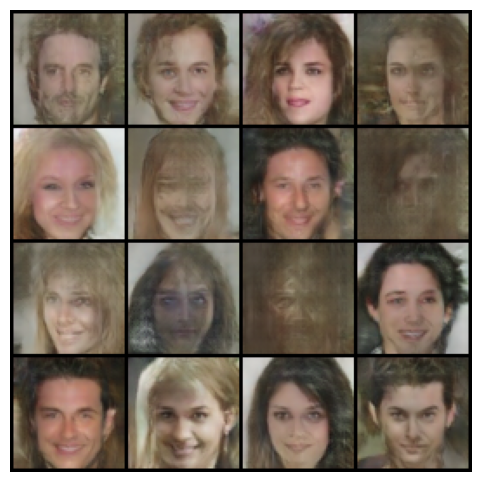

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
torch.save({"state_dict": gen.state_dict(), "z_dim": cfg.z_dim, "img_size": cfg.img_size},
           f"{cfg.out_dir}/generator_celeba64.pth")

@torch.no_grad()
def generate_faces(n=16, seed=None, trunc=1.0):
    """Return an (n,3,64,64) tensor in [0,1]. Pass `trunc` < 2.5 for cleaner, less diverse faces."""
    return sample_truncated(n, trunc, seed if seed is not None else random.randint(0, 10**6))

faces = generate_faces(16, seed=123)
plt.figure(figsize=(6, 6)); plt.imshow(make_grid(faces, nrow=4).permute(1, 2, 0)); plt.axis("off"); plt.show()

# Download results
!zip -q -r dcgan_outputs.zip /content/outputs
from google.colab import files
files.download("dcgan_outputs.zip")

## 9. Results summary

*(Fill these in from your own run: the numbers below come from the cells above.)*

| Item | Value |
|---|---|
| Dataset | CelebA, ~202k aligned faces, 64×64 |
| Architecture | DCGAN: G (4 transposed-conv blocks), D (4 strided-conv blocks) |
| Training | 25 epochs, batch 128, Adam lr 2e-4, ̢1 0.5, label smoothing 0.9 |
| Final FID (5k samples) | **27.5** |
| Best FID | **27.3** (at epoch 20) |
| Training time | **145.2 min** |

**Observations to write up honestly:**
- **FID Trend:** The FID consistently decreased over training, showing rapid progress in the first 10 epochs (dropping from 46.5 down to 31.9) before stabilizing near 27.3–27.5 by epochs 20–25.
- **D(x) and D(G(z)) Balance:** The discriminator became quite powerful towards the end. While initial stages were more balanced, eventually $D(x)$ rose towards 0.84 and $D(G(z))$ fell to 0.06. This indicates the Discriminator started to dominate slightly, forcing the Generator loss to rise to around 4.1.
- **Truncation Trade-off:** At `truncation = 2.5`, we observe highly diverse outputs but with some clear artifacts (asymmetry, chaotic textures). Lowering truncation to `1.0` or `0.5` significantly improves visual stability and facial coherence at the cost of diversity, resulting in cleaner, more typical faces but with highly repetitive, washed-out structures.

**Known limitations:** 64%64 resolution; no conditioning on attributes; FID computed on a 5k-image subset with upsampled low-res images, so use it to compare runs, not against published numbers; CelebA's demographic skew is reflected in the generated faces.